In [7]:
# Import robot_python_code.py
from robot_python_code import DataLoader
from parameters import trial_time

trial_time_1 = 7500
steer_angle_and_yaw_1 = [
    [+20, 180],
    [+20, 183],
    [-20, 180 + 47.5],
    [-20, 180 + 45],

    [15, 180 + 50],
    [15, 180 + 45],
    [-15, 170],
    [-15, 162],

    [+10, 180 + 90 + 15],
    [+10, 180 + 90 + 17],
    [-10, 90 + 26],
    [-10, 90 + 23],

    [+5, 180 + 90 + 64],
    [+5, 180 + 90 + 70],
    [-5, 62],
    [-5, 55],

    # [0, 270 + 85],
    # [0, 270 + 84],
]

trial_time_2 = 5000
steer_angle_and_yaw_2 = [
    [+20, 180 + 65],
    [+20, 180 + 60],
    [-20, 155],
    [-20, 157.5],

    [+15, 180 + 93],
    [+15, 180 + 95],
    [-15, 115],
    [-15, 115],

    [+10, 180 + 127.5],
    [+10, 180 + 90 + 41],
    [-10, 77],
    [-10, 78],

    [+5, 180 + 165],
    [+5, 180 + 165],
    [-5, 40],
    [-5, 42],

    # [0, 360 - 5],
    # [0, 360 - 7],
]

trial_time_3 = 15000
steer_angle_and_yaw_3 = [
    [+20, 3],
    [+20, 5],
    [-20, 360 + 105],
    [-20, 360 + 103],

    [+15, 91],
    [+15, 93],
    [-15, 180 + 90 + 77],
    [-15, 180 + 90 + 75], 

    [+10, 180 + 30],
    [+10, 180 + 30],
    [-10, 180 + 47], 
    [-10, 180 + 50], 

    [+5, 180 + 90 + 40],
    [+5, 180 + 90 + 38],
    [-5, 90 + 43],
    [-5, 130]
]

In [8]:
trial_data = []

for steer_angle, yaw in steer_angle_and_yaw_1:
    if steer_angle >= 0:
        yaw =  (360 - yaw)
    else:
        yaw = -yaw

    yaw_rate = yaw / trial_time_1

    trial_data.append({'yaw_rate': yaw_rate, 'steer_angle': steer_angle})

for steer_angle, yaw in steer_angle_and_yaw_2:
    if steer_angle >= 0:
        yaw =  (360 - yaw)
    else:
        yaw = -yaw

    yaw_rate = yaw / trial_time_2   

    trial_data.append({'yaw_rate': yaw_rate, 'steer_angle': steer_angle})

for steer_angle, yaw in steer_angle_and_yaw_3:
    if steer_angle >= 0:
        yaw =  (360 - yaw)
    else:
        yaw = -yaw

    yaw_rate = yaw / trial_time_3

    trial_data.append({'yaw_rate': yaw_rate, 'steer_angle': steer_angle})

# Sort by steering angle
trial_data = sorted(trial_data, key=lambda x: x['steer_angle'])

# print(*trial_data, sep='\n')

In [9]:
import matplotlib.pyplot as plt

x_data = [trial['steer_angle'] for trial in trial_data]
y_data = [trial['yaw_rate'] for trial in trial_data]

print(x_data)
print(y_data)

# plt.xlabel(f'Encoder Count $e$')
# plt.ylabel(f'Distance $s$ (meters)')
# plt.title('Distance Traveled vs Encoder Count')

# plt.plot(x_data, y_data, marker='o')

[-20, -20, -20, -20, -20, -20, -15, -15, -15, -15, -15, -15, -10, -10, -10, -10, -10, -10, -5, -5, -5, -5, -5, -5, 5, 5, 5, 5, 5, 5, 10, 10, 10, 10, 10, 10, 15, 15, 15, 15, 15, 15, 20, 20, 20, 20, 20, 20]
[-0.030333333333333334, -0.03, -0.031, -0.0315, -0.031, -0.030866666666666667, -0.02266666666666667, -0.0216, -0.023, -0.023, -0.023133333333333332, -0.023, -0.015466666666666667, -0.015066666666666667, -0.0154, -0.0156, -0.015133333333333334, -0.015333333333333332, -0.008266666666666667, -0.007333333333333333, -0.008, -0.0084, -0.008866666666666667, -0.008666666666666666, 0.0034666666666666665, 0.0026666666666666666, 0.003, 0.003, 0.0033333333333333335, 0.0034666666666666665, 0.01, 0.009733333333333333, 0.0105, 0.0098, 0.01, 0.01, 0.017333333333333333, 0.018, 0.0174, 0.017, 0.017933333333333332, 0.0178, 0.024, 0.0236, 0.023, 0.024, 0.0238, 0.023666666666666666]


LEFT : c1 = 1.5607240143e-03, c2 = 1.5412186380e-06
RIGHT: c1 = 7.6584229391e-04, c2 = 2.2293906810e-05

w(-20) = -3.059799e-02 deg/ms  ->  |w| = 3.059799e-02
w(+20) = 2.423441e-02 deg/ms  ->  |w| = 2.423441e-02
Asymmetry ratio |w(-20)| / |w(+20)| = 1.263


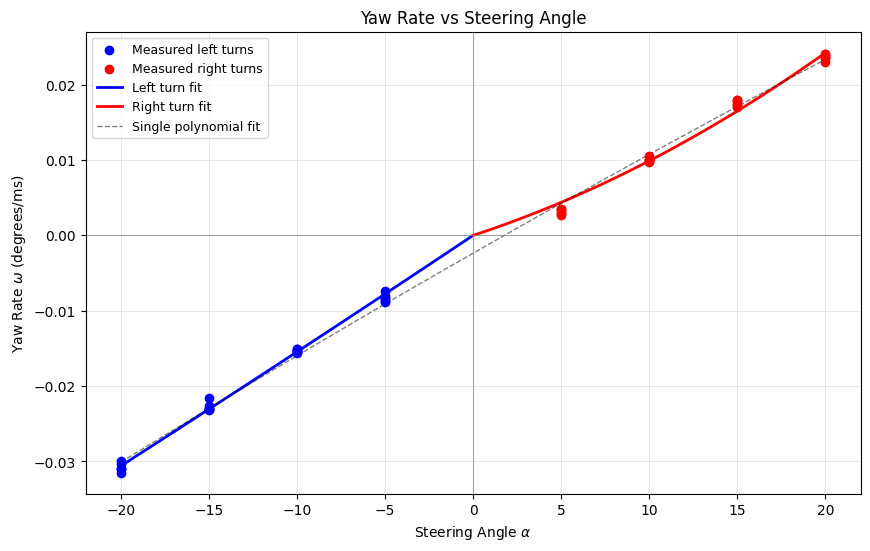

In [10]:
import numpy as np
from numpy.polynomial import Polynomial

x_data = np.array(x_data, dtype=np.float64)
y_data = np.array(y_data, dtype=np.float64)

# Split into left (negative) and right (positive)
mask_left = x_data < 0
mask_right = x_data > 0
x_left, y_left = x_data[mask_left], y_data[mask_left]
x_right, y_right = x_data[mask_right], y_data[mask_right]

# Fit degree-2 through origin (no constant term)
def fit_through_origin(x, y):
    A = np.column_stack([x, x**2])
    coeffs, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
    return coeffs  # [c1, c2]

def eval_poly(c, x):
    return c[0] * x + c[1] * x**2

c_left = fit_through_origin(x_left, y_left)
c_right = fit_through_origin(x_right, y_right)

print(f"LEFT : c1 = {c_left[0]:.10e}, c2 = {c_left[1]:.10e}")
print(f"RIGHT: c1 = {c_right[0]:.10e}, c2 = {c_right[1]:.10e}")
print(f"\nw(-20) = {eval_poly(c_left, -20):.6e} deg/ms  ->  |w| = {abs(eval_poly(c_left, -20)):.6e}")
print(f"w(+20) = {eval_poly(c_right, 20):.6e} deg/ms  ->  |w| = {abs(eval_poly(c_right, 20)):.6e}")
print(f"Asymmetry ratio |w(-20)| / |w(+20)| = {abs(eval_poly(c_left, -20)) / abs(eval_poly(c_right, 20)):.3f}")

# Also show previous single polynomial for comparison
p_single = Polynomial.fit(x_data, y_data, deg=2).convert()

# Plot
x_plot_left = np.linspace(-20, 0, 100)
x_plot_right = np.linspace(0, 20, 100)
x_plot_all = np.linspace(-20, 20, 200)

plt.figure(figsize=(10, 6))
plt.scatter(x_left, y_left, color='blue', label='Measured left turns', zorder=5)
plt.scatter(x_right, y_right, color='red', label='Measured right turns', zorder=5)
plt.plot(x_plot_left, eval_poly(c_left, x_plot_left), 'b-', linewidth=2, label=f'Left turn fit')
plt.plot(x_plot_right, eval_poly(c_right, x_plot_right), 'r-', linewidth=2, label=f'Right turn fit')
plt.plot(x_plot_all, p_single(x_plot_all), 'k--', linewidth=1, alpha=0.5, label='Single polynomial fit')
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)

plt.xlabel(f'Steering Angle $\\alpha$')
plt.ylabel(f'Yaw Rate $\\omega$ (degrees/ms)')
plt.title(f'Yaw Rate vs Steering Angle')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()

In [11]:
# Squared residuals per side
resid_left = (y_left - eval_poly(c_left, x_left)) ** 2
resid_right = (y_right - eval_poly(c_right, x_right)) ** 2

# Fit variance as degree-2 polynomial through origin: var = v1*α + v2*α²
v_left = fit_through_origin(x_left, resid_left)
v_right = fit_through_origin(x_right, resid_right)

print(f"LEFT : v1 = {v_left[0]:.10e}, v2 = {v_left[1]:.10e}")
print(f"RIGHT: v1 = {v_right[0]:.10e}, v2 = {v_right[1]:.10e}")
print(f"\nvar(-20) = {eval_poly(v_left, -20):.6e},  var(-5) = {eval_poly(v_left, -5):.6e}")
print(f"var(+20) = {eval_poly(v_right, 20):.6e},  var(+5) = {eval_poly(v_right, 5):.6e}")

LEFT : v1 = -4.8725465517e-08, v2 = -1.7897854046e-09
RIGHT: v1 = 1.8038574058e-07, v2 = -7.9043028987e-09

var(-20) = 2.585951e-07,  var(-5) = 1.988827e-07
var(+20) = 4.459937e-07,  var(+5) = 7.043211e-07


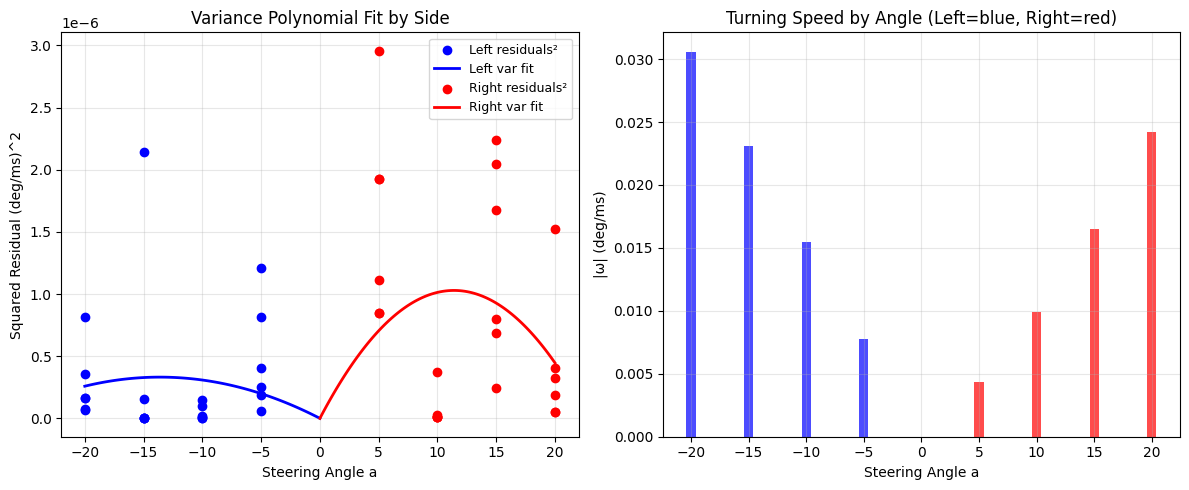


=== Copy-paste for motion_models.py ===

# Rotational velocity: w = c1 * a + c2 * a**2  (deg/ms)
# LEFT  (a < 0):
w = 1.5607240143e-03 * a + 1.5412186380e-06 * a**2
# RIGHT (a > 0):
w = 7.6584229391e-04 * a + 2.2293906810e-05 * a**2

# Variance of rotational velocity: var_w = v1 * a + v2 * a**2  (deg/ms)^2
# LEFT  (a < 0):
var_w = -4.8725465517e-08 * a + -1.7897854046e-09 * a**2
# RIGHT (a > 0):
var_w = 1.8038574058e-07 * a + -7.9043028987e-09 * a**2


In [12]:
# Visualize variance fit
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

x_vl = np.linspace(-20, 0, 100)
x_vr = np.linspace(0, 20, 100)

ax1.scatter(x_left, resid_left, color='blue', label='Left residuals²', zorder=5)
ax1.plot(x_vl, eval_poly(v_left, x_vl), 'b-', linewidth=2, label='Left var fit')
ax1.scatter(x_right, resid_right, color='red', label='Right residuals²', zorder=5)
ax1.plot(x_vr, eval_poly(v_right, x_vr), 'r-', linewidth=2, label='Right var fit')
ax1.set_xlabel('Steering Angle a')
ax1.set_ylabel('Squared Residual (deg/ms)^2')
ax1.set_title('Variance Polynomial Fit by Side')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Turning speed comparison
angles = [-20, -15, -10, -5, 5, 10, 15, 20]
w_vals = [eval_poly(c_left, a) if a < 0 else eval_poly(c_right, a) for a in angles]
ax2.bar(angles, [abs(w) for w in w_vals], color=['blue']*4 + ['red']*4, alpha=0.7)
ax2.set_xlabel('Steering Angle a')
ax2.set_ylabel('|ω| (deg/ms)')
ax2.set_title('Turning Speed by Angle (Left=blue, Right=red)')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Copy-paste for motion_models.py ===\n")
print("# Rotational velocity: w = c1 * a + c2 * a**2  (deg/ms)")
print(f"# LEFT  (a < 0):")
print(f"w = {c_left[0]:.10e} * a + {c_left[1]:.10e} * a**2")
print(f"# RIGHT (a > 0):")
print(f"w = {c_right[0]:.10e} * a + {c_right[1]:.10e} * a**2")
print()
print("# Variance of rotational velocity: var_w = v1 * a + v2 * a**2  (deg/ms)^2")
print(f"# LEFT  (a < 0):")
print(f"var_w = {v_left[0]:.10e} * a + {v_left[1]:.10e} * a**2")
print(f"# RIGHT (a > 0):")
print(f"var_w = {v_right[0]:.10e} * a + {v_right[1]:.10e} * a**2")